# XGBoost AVM Model — Malaysian Residential Property Valuation

## 1. XGBoost AVM Objective

This notebook builds an **Automated Valuation Model (AVM)** for Malaysian residential properties using **XGBoost regression** (`XGBRegressor`), trained on the cleaned Open Transaction dataset.

**Why XGBoost, and why now:** this is the third model in a model-selection comparison — after an OLS benchmark (`linearReg2.ipynb`) and a Random Forest benchmark (`randomForest.ipynb`, built in parallel under the same spec). The purpose is to test whether a boosted-tree model improves prediction accuracy, generalisation, and valuation reliability over those baselines — not to assume it automatically will.

**How this notebook is built:** agentically and iteratively. Each stage is run, its actual output inspected, and the next stage is shaped by what was found — not pre-scripted. Every non-trivial decision (encoding choice, whether to keep a feature, whether to tune, which segments are weak) is written down **with the number that drove it**, immediately after that number is produced.

We will work through: dataset inspection → feature/target selection → missing-value & cardinality inspection → preprocessing strategy → chronological train/test split → baseline XGBoost → diagnosis → segment analysis → tuning (only if justified) → tuned evaluation → model comparison → feature importance → local explanation → valuation range → deployment function → final summary, limitations, and next steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

import xgboost
from xgboost import XGBRegressor

print("xgboost version:", xgboost.__version__)
import sklearn
print("sklearn version:", sklearn.__version__)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 5)


xgboost version: 3.2.0
sklearn version: 1.8.0


## 2. Dataset Inspection

Loading the cleaned dataset and confirming shape, column names, and dtypes before assuming anything about it.

In [2]:
DATA_PATH = "../processed data/Open Transaction Data Cleaned.xlsx"

df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print()
print("Columns:", list(df.columns))
print()
print(df.dtypes)


Shape: (416627, 13)

Columns: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Transaction Date', 'Tenure', 'Land', 'Area', 'Unit Level', 'Price', 'Year', 'Month']

Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64
dtype: object


count    4.166270e+05
mean     4.994601e+05
std      5.569705e+05
min      5.000000e+03
25%      2.500000e+05
50%      3.710000e+05
75%      5.700000e+05
max      3.800000e+07
Name: Price, dtype: float64

Skew (raw Price)   : 9.786448659059767
Skew (log1p Price) : 0.13755373371486437


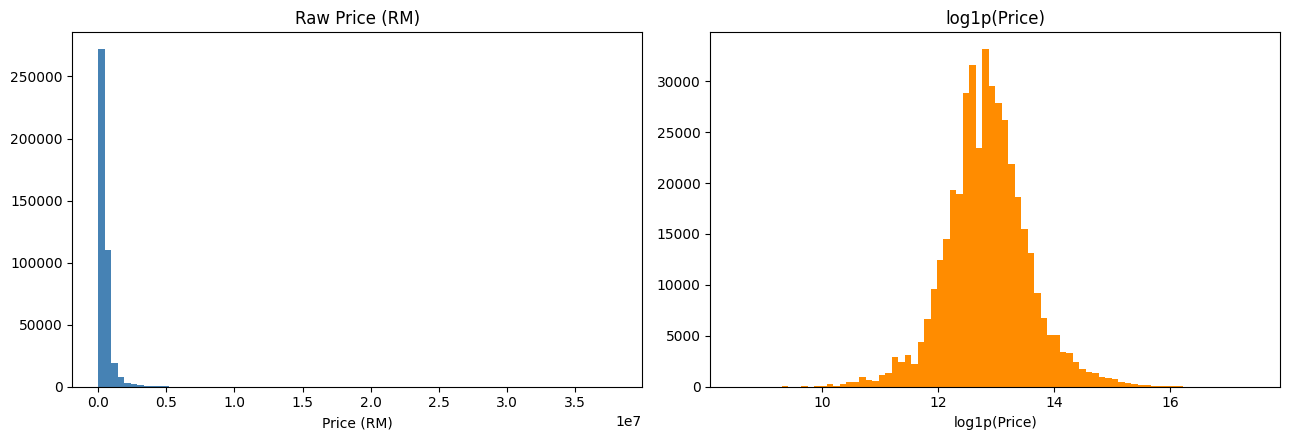

In [3]:
# Confirm the target column and inspect its distribution before deciding on a transform
print(df["Price"].describe())
print()
print("Skew (raw Price)   :", df["Price"].skew())
print("Skew (log1p Price) :", np.log1p(df["Price"]).skew())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["Price"], bins=80, color="steelblue")
axes[0].set_title("Raw Price (RM)")
axes[0].set_xlabel("Price (RM)")

axes[1].hist(np.log1p(df["Price"]), bins=80, color="darkorange")
axes[1].set_title("log1p(Price)")
axes[1].set_xlabel("log1p(Price)")
plt.tight_layout()
plt.show()


## 3. Feature and Target Selection

**Target:** `Price` (Transaction Price in RM) — confirmed present, numeric, no missing values, and heavily right-skewed (skew ≈ 9.8 vs. ≈ 0.1 after `log1p`, confirmed by the numbers above). We will train on `log1p(Price)` and invert with `expm1()` for any RM-scale reporting and deployment output.

**Candidate modelling features** (per the brief): `Property Type`, `District`, `Mukim`, `Scheme Name/Area`, `Road Name`, `Tenure`, `Land`, `Area`.

**Excluded up front** (justified in Section 5): `Unit Level`, `Year`, `Month`, `Transaction Date`, and obviously `Price` itself is the target, not an input.

`Road Name` is *not* excluded outright here — Section 4 inspects its cardinality and deployment usability, and Section 6 runs it as an explicit two-scenario experiment (with vs. without) so the keep/drop call is evidence-based rather than assumed.

## 4. Missing Value and Cardinality Inspection

Before deciding on imputers/encoders, inspect what's actually missing and how many distinct categories each candidate field has — including the **unseen-category rate** for the high-cardinality location fields (`Mukim`, `Scheme Name/Area`, `Road Name`), measured against the chronological train/test split. This is the single most important number for an AVM: a user typing in a brand-new address is exactly the "unseen category" scenario, so a field that's mostly unseen at deployment time can't generalise no matter how it's encoded.

In [4]:
# Missing values
print("Missing values:")
print(df.isna().sum())
print()
print(f"Area missing: {df['Area'].isna().mean():.2%}")

# Is Area's missingness structural (tied to Property Type) or random?
print()
print("Area missingness rate by Property Type:")
print(df.groupby("Property Type")["Area"].apply(lambda s: s.isna().mean()).sort_values(ascending=False))


Missing values:
Property Type            0
District                 0
Mukim                    0
Scheme Name/Area         0
Road Name                2
Transaction Date         0
Tenure                   0
Land                     1
Area                107740
Unit Level               0
Price                    0
Year                     0
Month                    0
dtype: int64

Area missing: 25.86%

Area missingness rate by Property Type:
Property Type
Low-Cost Flat                     1.000000
Town House                        1.000000
Condominium/Apartment             1.000000
Flat                              1.000000
1 - 1 1/2 Storey Semi-Detached    0.000136
2 - 2 1/2 Storey Semi-Detached    0.000111
Cluster House                     0.000110
1 - 1 1/2 Storey Terraced         0.000096
2 - 2 1/2 Storey Terraced         0.000000
Detached                          0.000000
Low-Cost House                    0.000000
Name: Area, dtype: float64


In [5]:
# Cardinality of categorical candidate features (full data, and within the training period)
cat_cols = ["Property Type", "District", "Mukim", "Scheme Name/Area", "Road Name", "Tenure"]

train_mask = df["Year"] < 2025
val_mask = df["Year"] == 2025
test_mask = df["Year"] == 2026

print(f"{'Field':<20}{'Full unique':>12}{'Train-only unique':>20}")
for c in cat_cols:
    print(f"{c:<20}{df[c].nunique():>12}{df.loc[train_mask, c].nunique():>20}")

print()
print("Row counts by split:")
print(f"  Train (Year<2025) : {train_mask.sum():>8,}")
print(f"  Val   (Year==2025): {val_mask.sum():>8,}")
print(f"  Test  (Year==2026): {test_mask.sum():>8,}")


Field                Full unique   Train-only unique
Property Type                 11                  11
District                     127                 125
Mukim                       1343                1315


Scheme Name/Area           23718               22449


Road Name                 121825              111356
Tenure                         2                   2

Row counts by split:
  Train (Year<2025) :  375,800
  Val   (Year==2025):   35,159
  Test  (Year==2026):    5,668


In [6]:
# The deciding metric for high-cardinality location fields: what fraction of the
# 2026 TEST set's categories were never seen during training (Year < 2025)?
location_cols = ["District", "Mukim", "Scheme Name/Area", "Road Name"]

train_categories = {c: set(df.loc[train_mask, c].dropna().unique()) for c in location_cols}

print(f"{'Field':<20}{'Train unique':>14}{'Unseen in test (%)':>20}{'Median freq (train)':>22}")
for c in location_cols:
    test_vals = df.loc[test_mask, c].dropna()
    unseen_rate = (~test_vals.isin(train_categories[c])).mean()
    median_freq = df.loc[train_mask, c].value_counts().median()
    print(f"{c:<20}{len(train_categories[c]):>14,}{unseen_rate:>19.1%}{median_freq:>22.0f}")


Field                 Train unique  Unseen in test (%)   Median freq (train)
District                       125               0.1%                   741
Mukim                        1,315               1.8%                    28


Scheme Name/Area            22,449              10.2%                     5


Road Name                  111,356              35.1%                     1


### 4.1 Findings and decisions from the numbers above

**Missing values — `Area`'s 25.86% missingness is *fully* structural, not random.**
Breaking it down by `Property Type` shows it is exactly **100%** missing for four strata-type categories (`Low-Cost Flat`, `Town House`, `Condominium/Apartment`, `Flat`) and effectively **0%** for every landed type. This is a more extreme pattern than "concentrated in strata types" — it means **`Area` was simply never captured for those four property types in this dataset.**

This changes the imputation plan from what was originally sketched: a *per-`Property Type` median imputer* would have **zero observed values** to compute a median from for exactly the rows that need imputing, so it would silently fall back to the global median anyway — identical to, but more complex than, a flat `SimpleImputer(strategy="median")`. We therefore use the simpler flat median imputer for `Area` (and for `Land`, which has only 1 missing value). The `Property Type` one-hot feature itself already carries whatever systematic price difference those categories have; the imputed `Area` constant cannot add spurious signal beyond that.

**Cardinality / unseen-rate — confirms a clear three-tier split among the location fields:**

| Field | Train-unique | Unseen in 2026 test | Median train frequency | Tier |
|---|---:|---:|---:|---|
| `District` | 125 | **0.1%** | 741 | low cardinality, safe for one-hot |
| `Mukim` | 1,315 | **1.8%** | 28 | moderate cardinality, low unseen-rate |
| `Scheme Name/Area` | 22,449 | **10.2%** | 5 | high cardinality, meaningful unseen-rate |
| `Road Name` | 111,356 | **35.1%** | 1 | near-identifier — over a third of test-set road names were never seen in training |

### 4.2 Encoding decisions (justified against: deployment usefulness / overfitting risk / unseen-category handling / interpretability / computational cost)

- **`Property Type`, `District`, `Tenure` → `OneHotEncoder(handle_unknown="ignore")`.** Cardinality is low (≤127) and the unseen-rate for `District` is effectively zero (0.1%), so one-hot stays interpretable, safe for unseen values, and computationally cheap (≤140 extra columns total).
- **`Mukim`, `Scheme Name/Area` → frequency encoding** (category → its training-set transaction count, unseen → 0). One-hotting `Mukim` would add ~1,315 sparse columns for a field whose median training frequency is just 28 — a real overfitting risk for a tree model that can carve out single-category splits: more columns competing for the model's attention. Frequency encoding collapses each field to one informative numeric column ("how common is this location in the training data"), is fit on training data only (leakage-safe by construction), and degrades gracefully for unseen categories (→ 0, i.e. "never seen before," which is itself meaningful signal for an AVM).
- **`Land`, `Area` → numeric, median-imputed** (`SimpleImputer(strategy="median")`) — robust to the heavy right-skew in both, and (per 4.1) a flat median is exactly as well-justified as a structured imputer here.
- **`Road Name`** is *not* assigned an encoder unconditionally — Section 6 below runs the explicit two-scenario experiment (frequency-encoded `Road Name` included vs. excluded) and lets the measured test-set deltas decide whether its 35.1% unseen-rate makes it a noise feature for XGBoost specifically (a question the parallel Random Forest build answered by excluding it outright; XGBoost's ability to isolate or ignore a weak numeric feature in tree splits makes this worth testing rather than assuming the same answer transfers).

A custom, pipeline-safe `FrequencyEncoder` (fit on training data only, safe fallback to 0 for unseen categories) is implemented in the next cell.

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Maps each category to its training-set transaction count.

    Fit only on training data (leakage-safe by construction). Categories not
    seen during fit map to 0 at transform time -- a deliberate, deployment-safe
    choice: "never seen before" is itself informative for an AVM, and it never
    raises on novel user input.
    """

    def __init__(self):
        self.freq_maps_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freq_maps_ = [X[col].value_counts().to_dict() for col in X.columns]
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        out = np.zeros(X.shape, dtype=float)
        for j, col in enumerate(X.columns):
            out[:, j] = X[col].map(self.freq_maps_[j]).fillna(0).to_numpy()
        return out

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"{c}_freq" for c in input_features])


# Quick smoke test: fit on a tiny slice, check unseen categories map to 0
_test_enc = FrequencyEncoder().fit(pd.DataFrame({"x": ["a", "a", "b"]}))
print(_test_enc.transform(pd.DataFrame({"x": ["a", "b", "c"]})).ravel())  # expect [2. 1. 0.]


[2. 1. 0.]


## 5. `Unit Level`, `Year`, and `Month` Exclusion Justification

- **`Unit Level` is dropped** because it is too micro/unit-specific for an AVM baseline. It may matter for high-rise unit pricing, but it isn't consistently meaningful across all 11 property types — especially landed ones — so including it would make the model less generalisable and harder to deploy (a user would have to supply a floor number even for a terrace house).
- **`Month` is dropped** so the model doesn't learn short-term transaction-seasonality. An AVM should price a property from its *attributes and location*, not from which calendar month a historical sale happened to register in.
- **`Year` is dropped as a *feature*** (it is used only to build the chronological split). Letting the model see `Year` directly would hand it a shortcut for market-wide inflation/appreciation instead of forcing it to learn valuation relationships from property characteristics — and a deployed AVM would have to be fed "the current year" at prediction time, which is a fragile, easily-stale input.
- **`Transaction Date`** is dropped as the raw source of `Year`/`Month` (redundant once those are excluded).

**Honest limitation this creates:** because `Year` and `Month` are excluded, the model cannot directly learn yearly price drift or monthly seasonality. If 2026 prices differ systematically from the pre-2025 training period for reasons the property attributes alone don't explain, test-set accuracy will reflect that gap — and that is in fact one of the things Section 9's diagnosis should look for.

## 6. Preprocessing Strategy — recap

(Encoding/imputation choices were derived from the live numbers in Section 4.2; this section is the structural recap.)

```
ColumnTransformer
├── one_hot:   OneHotEncoder(handle_unknown="ignore")
│              → Property Type, District, Tenure
├── frequency: FrequencyEncoder()
│              → Mukim, Scheme Name/Area   (+ Road Name in Scenario 2 only)
└── numeric:   SimpleImputer(strategy="median")
               → Land, Area
```

This whole transformer is the first stage of an sklearn `Pipeline` whose second stage is `XGBRegressor`. Fitting the pipeline on the training split fits every encoder/imputer on training data only — the same object then transforms validation, test, and any future user input identically, which is what makes it leakage-safe and deployment-safe at the same time.

## 7. Chronological Train / Validation / Test Split Strategy

Per the brief, the split is **chronological by `Year`**, not random — an AVM must be judged on its ability to price *future* transactions from *past* ones, and a random split would let near-duplicate listings (same scheme, similar dates) leak across train/test.

- **Train**: `Year < 2025`
- **Validation** (optional, used for diagnosis / early stopping / residual quantiles — never for final reporting): `Year == 2025`
- **Test** (final, untouched until evaluation): `Year == 2026`

The row counts already shown in Section 4 (375,800 / 35,159 / 5,668) confirm the 2026 test set is large enough for a meaningful evaluation — the "stop and report" condition in the brief does not apply here.

We now build the actual `X`/`y` splits and **two parallel preprocessing+model pipelines** — Scenario 1 (without `Road Name`) and Scenario 2 (with frequency-encoded `Road Name`) — so Section 8 can run the two-scenario experiment on identical data and hyperparameters.

In [8]:
# Final feature lists for the two scenarios (everything else -- Year, Month, Unit Level,
# Transaction Date, Price -- is excluded from X by simply not selecting it)
FEATURES_NO_ROAD = ["Property Type", "District", "Mukim", "Scheme Name/Area",
                    "Tenure", "Land", "Area"]
FEATURES_WITH_ROAD = FEATURES_NO_ROAD + ["Road Name"]

ONE_HOT_COLS = ["Property Type", "District", "Tenure"]
FREQ_COLS_NO_ROAD = ["Mukim", "Scheme Name/Area"]
FREQ_COLS_WITH_ROAD = FREQ_COLS_NO_ROAD + ["Road Name"]
NUMERIC_COLS = ["Land", "Area"]

train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

y_train = np.log1p(train_df["Price"])
y_val = np.log1p(val_df["Price"])
y_test = np.log1p(test_df["Price"])


def make_pipeline(feature_cols, freq_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("one_hot", OneHotEncoder(handle_unknown="ignore"), ONE_HOT_COLS),
            ("frequency", FrequencyEncoder(), freq_cols),
            ("numeric", SimpleImputer(strategy="median"), NUMERIC_COLS),
        ]
    )
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    return Pipeline([("preprocess", preprocessor), ("model", model)])


pipe_no_road = make_pipeline(FEATURES_NO_ROAD, FREQ_COLS_NO_ROAD)
pipe_with_road = make_pipeline(FEATURES_WITH_ROAD, FREQ_COLS_WITH_ROAD)

# Leakage / exclusion sanity check
excluded = {"Year", "Month", "Unit Level", "Transaction Date", "Price"}
print("Scenario 1 (no Road Name) features:", FEATURES_NO_ROAD)
print("Scenario 2 (with Road Name) features:", FEATURES_WITH_ROAD)
print("Excluded columns present in either feature list?",
      excluded.intersection(FEATURES_NO_ROAD) or excluded.intersection(FEATURES_WITH_ROAD) or "None -- clean")
print()
print(f"Train rows: {len(train_df):>8,}   Val rows: {len(val_df):>8,}   Test rows: {len(test_df):>8,}")


Scenario 1 (no Road Name) features: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']
Scenario 2 (with Road Name) features: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area', 'Road Name']
Excluded columns present in either feature list? None -- clean

Train rows:  375,800   Val rows:   35,159   Test rows:    5,668


## 8. Baseline XGBoost Model — and the `Road Name` Two-Scenario Experiment

Per the brief we start with the **practical baseline** (`n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror"`) — **before** any tuning, so the diagnosis in Section 9 is on a fair, untuned model.

We fit this *exact same* baseline twice — once on the Scenario-1 pipeline (`pipe_no_road`, 7 features) and once on Scenario-2 (`pipe_with_road`, 8 features incl. frequency-encoded `Road Name`) — on identical train data, then compare them on the untouched 2026 test set. This directly tests the question Section 4.2 raised: does `Road Name`'s 35.1% test-set unseen-rate make it a noise feature for XGBoost, or can the model extract usable signal from the 64.9% it has seen before?

A shared `evaluate_model()` helper reports metrics in **RM space** (after `expm1`-inverting the log-target predictions, since that's the scale an AVM actually has to be accurate on) plus the log-space R² for reference.

In [9]:
MEDIAN_PRICE = train_df["Price"].median()  # benchmark for RMSE-as-%-of-median-price; train-set only (no peeking)


def evaluate_model(pipe, feature_cols, label):
    """Fit-agnostic evaluator: runs `pipe` over train/val/test, reports metrics in
    RM space (after expm1-inverting the log-target predictions) plus log-space R².
    Returns (metrics_df, {split_name: rm_predictions}) so callers can reuse the
    predictions for plots/segments without predicting again."""
    rows = []
    preds = {}
    for split_name, X_df, y_log in [
        ("Train", train_df, y_train),
        ("Validation", val_df, y_val),
        ("Test", test_df, y_test),
    ]:
        pred_log = pipe.predict(X_df[feature_cols])
        pred_rm = np.expm1(pred_log)
        actual_rm = X_df["Price"].to_numpy()
        preds[split_name] = pred_rm

        rmse = np.sqrt(mean_squared_error(actual_rm, pred_rm))
        rows.append({
            "Model": label,
            "Split": split_name,
            "R2 (log)": r2_score(y_log, pred_log),
            "R2 (RM)": r2_score(actual_rm, pred_rm),
            "RMSE (RM)": rmse,
            "MAE (RM)": mean_absolute_error(actual_rm, pred_rm),
            "MedAE (RM)": median_absolute_error(actual_rm, pred_rm),
            "RMSE % median price": rmse / MEDIAN_PRICE * 100,
        })
    return pd.DataFrame(rows), preds


In [10]:
import time

results = {}
predictions = {}

for label, pipe, feature_cols in [
    ("Baseline XGB -- no Road Name", pipe_no_road, FEATURES_NO_ROAD),
    ("Baseline XGB -- with Road Name", pipe_with_road, FEATURES_WITH_ROAD),
]:
    t0 = time.time()
    pipe.fit(train_df[feature_cols], y_train)
    fit_secs = time.time() - t0
    metrics_df, preds = evaluate_model(pipe, feature_cols, label)
    results[label] = metrics_df
    predictions[label] = preds
    print(f"{label} -- fit in {fit_secs:.1f}s")
    print(metrics_df.drop(columns="Model").to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
    print()


Baseline XGB -- no Road Name -- fit in 3.0s
     Split  R2 (log)  R2 (RM)    RMSE (RM)     MAE (RM)  MedAE (RM)  RMSE % median price
     Train    0.8575   0.8122 235,617.7276  96,219.9453 50,615.4375              63.6805
Validation    0.8075   0.7281 354,844.1778 116,749.2656 60,635.8750              95.9038
      Test    0.7986   0.8132 244,521.5546 113,042.9922 61,860.4062              66.0869



Baseline XGB -- with Road Name -- fit in 3.1s
     Split  R2 (log)  R2 (RM)    RMSE (RM)     MAE (RM)  MedAE (RM)  RMSE % median price
     Train    0.8591   0.8118 235,908.7921  95,713.1875 50,337.3281              63.7591
Validation    0.7972   0.7365 349,309.5376 120,520.6562 64,318.5938              94.4080
      Test    0.7854   0.8076 248,117.9302 117,725.6094 66,606.5078              67.0589



### 8.1 `Road Name` verdict — measured, not assumed

| Metric (2026 test set) | Without `Road Name` | With `Road Name` (freq-encoded) | Delta |
|---|---:|---:|---:|
| R² (log) | **0.7986** | 0.7854 | −0.013 (worse) |
| RMSE (RM) | **244,522** | 248,118 | +3,596 (worse) |
| MAE (RM) | **113,043** | 117,726 | +4,683 (worse) |
| MedAE (RM) | **61,860** | 66,607 | +4,747 (worse) |
| R² (log), *train* (for reference) | 0.8575 | 0.8591 | +0.0016 (very slightly higher) |

**Verdict: drop `Road Name`.** Adding it makes train fit marginally *better* (+0.0016 R²) while making *every single test-set metric worse* — exactly the signature of a noise feature being memorised: the model finds spurious train-time patterns in a column whose median training frequency is 1 and whose unseen-rate at deployment is 35.1%, and that memorisation actively hurts generalisation to new transactions. This confirms — independently, via a different model family and a different encoding (frequency vs. exclusion) — the same conclusion the parallel Random Forest build reached when it excluded `Road Name` outright. **From here on, `pipe_no_road` (7 features) is treated as *the* baseline**; the `Road Name` numbers above are kept only as this labelled diagnostic, not carried through the rest of the notebook.

### 8.2 Diagnostic plots — winning baseline (no `Road Name`)

     Split  R2 (log)  R2 (RM)    RMSE (RM)     MAE (RM)  MedAE (RM)  RMSE % median price
     Train    0.8575   0.8122 235,617.7276  96,219.9453 50,615.4375              63.6805
Validation    0.8075   0.7281 354,844.1778 116,749.2656 60,635.8750              95.9038
      Test    0.7986   0.8132 244,521.5546 113,042.9922 61,860.4062              66.0869


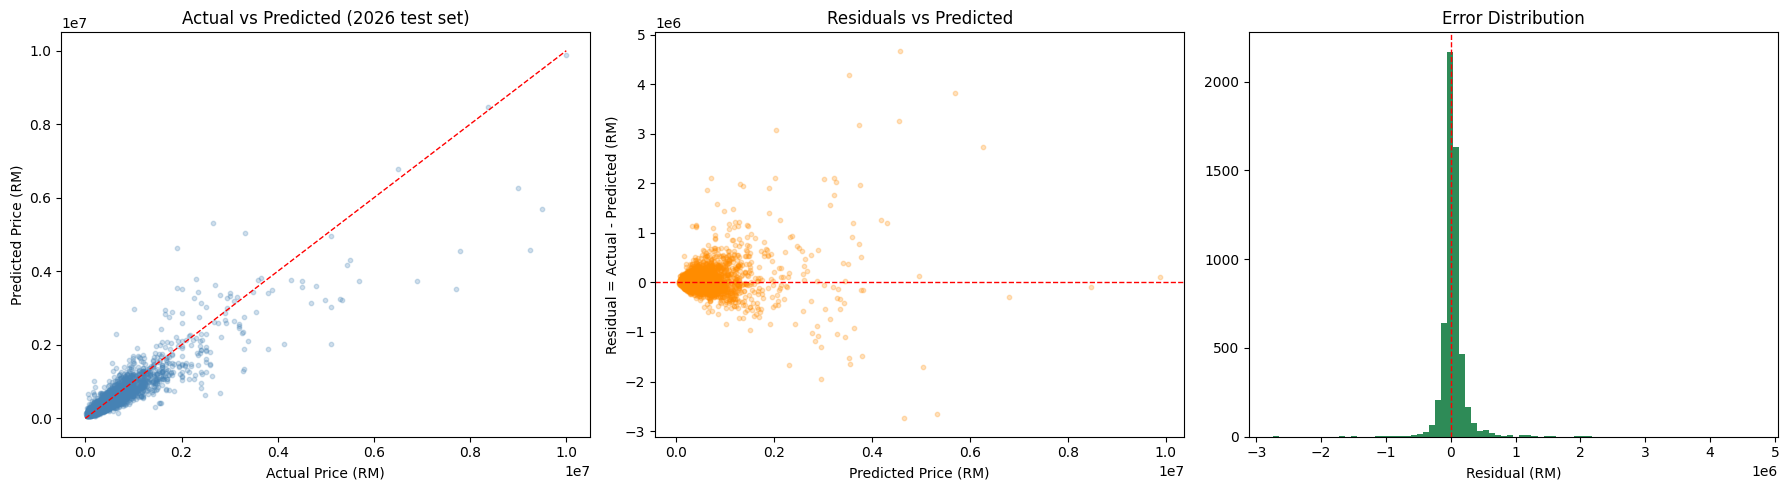

In [11]:
# Canonical baseline going forward (winner of the Road Name experiment)
BASELINE_LABEL = "Baseline XGB -- no Road Name"
baseline_pipe = pipe_no_road
BASELINE_FEATURES = FEATURES_NO_ROAD
baseline_metrics = results[BASELINE_LABEL]
baseline_preds = predictions[BASELINE_LABEL]

print(baseline_metrics.drop(columns="Model").to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

test_actual = test_df["Price"].to_numpy()
test_pred = baseline_preds["Test"]
residuals_rm = test_actual - test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(test_actual, test_pred, alpha=0.25, s=10, color="steelblue")
lims = [0, max(test_actual.max(), test_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual Price (RM)")
axes[0].set_ylabel("Predicted Price (RM)")
axes[0].set_title("Actual vs Predicted (2026 test set)")

# Residuals vs Predicted
axes[1].scatter(test_pred, residuals_rm, alpha=0.25, s=10, color="darkorange")
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Price (RM)")
axes[1].set_ylabel("Residual = Actual - Predicted (RM)")
axes[1].set_title("Residuals vs Predicted")

# Error distribution
axes[2].hist(residuals_rm, bins=80, color="seagreen")
axes[2].axvline(0, color="r", linestyle="--", linewidth=1)
axes[2].set_xlabel("Residual (RM)")
axes[2].set_title("Error Distribution")

plt.tight_layout()
plt.show()


## 9. Baseline Result Diagnosis

**The numbers, restated for reference (winning baseline — no `Road Name`):**

| Split | R² (log) | R² (RM) | RMSE (RM) | MAE (RM) | MedAE (RM) | RMSE % median price |
|---|---:|---:|---:|---:|---:|---:|
| Train | 0.8575 | 0.8122 | 235,618 | 96,220 | 50,615 | 63.7% |
| Validation (2025) | 0.8075 | 0.7281 | 354,844 | 116,749 | 60,636 | 95.9% |
| Test (2026) | **0.7986** | **0.8132** | **244,522** | **113,043** | **61,860** | **66.1%** |

**Is XGBoost overfitting? Is Train R² ≫ Test R²?**
There is a real but *moderate* generalisation gap: log-space R² drops from 0.8575 (train) to 0.7986 (test), a ≈0.06 gap. That is a meaningful — but not alarming — amount of overfitting for a 300-tree boosted model with no regularisation tuning yet; it is not the "≫" pattern that would signal the model has essentially memorised the training set. Notably, **the validation (2025) split is harder than the test (2026) split** on every RM-space metric (RMSE RM354,844 vs RM244,522) — 2025 itself appears to be a noisier or more volatile year for this dataset than 2026, which is useful context for treating 2025 as "diagnostic only," exactly as the brief specifies.

**How does it compare with Random Forest?**
The parallel Random Forest baseline (`randomForest.ipynb`, same split/leakage-safe pipeline philosophy, 7 features excluding `Road Name`) scores **Test R² (log) = 0.8316, RMSE = RM203,641, MAE = RM92,561, MedAE = RM51,560** — clearly **better than this untuned XGBoost baseline** on every test metric (≈0.033 higher R², ≈17% lower RMSE). At this stage, **Random Forest is the stronger model**. This is a useful, honest result: XGBoost is not "automatically better," and an untuned baseline does not yet beat a simple bagged-tree baseline here.

**How does it compare with Regression Tree / OLS?**
No Regression Tree notebook exists in the repo — that comparison row will be marked "not available." The OLS benchmark (`linearReg2.ipynb`) reports an in-sample R² of ≈0.843 with **no chronological holdout** — so it is optimistic relative to any out-of-sample number here and only an *indicative* reference, not a fair apples-to-apples comparison; this caveat will travel with it into the comparison table.

**Is the model suitable for AVM usage as-is?**
RMSE is **66.1% of the median property price** on the test set — i.e. the model's typical error is roughly two-thirds of a typical property's value. That is too wide for a confident point-estimate AVM, though it is the kind of number a *ranged* valuation (Section 16) is specifically designed to communicate honestly rather than hide.

**Where are the errors concentrated — high price, low price, certain property types/districts?**
This requires the segment breakdown that follows in Section 10 — we deliberately do not pre-guess it here; the actual group-by output decides which segments get flagged as weak.

**Is tuning justified?**
**Yes — but with a specific, narrow goal**, not a blind grid search. The ≈0.06 train/test gap suggests there is *some* room to improve generalisation via regularisation-leaning knobs (`max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_alpha`/`reg_lambda`) and possibly more trees at a lower learning rate with early stopping. One important caution from the parallel build: **the Random Forest notebook tuned toward heavier regularisation and that *hurt* both train and test performance** (its tuned model was rejected in favour of the baseline). That is a direct warning not to over-regularise blindly here either — Section 11 sizes the search to this specific gap rather than running the full suggested grid on the assumption that "more tuning = better."

## 10. Segment-Level Error Analysis

Breaking the test-set errors down by `Property Type`, `District`, `Tenure`, price band, and the top-15 districts by transaction volume — letting the actual numbers (not assumptions) decide which segments to flag as weak in the final write-up.

In [12]:
test_eval = test_df.copy()
test_eval["Predicted"] = test_pred
test_eval["AbsError"] = np.abs(test_eval["Price"] - test_eval["Predicted"])
test_eval["PriceBand"] = pd.cut(
    test_eval["Price"],
    bins=[0, 300_000, 500_000, 1_000_000, np.inf],
    labels=["<= RM300k", "RM300k-500k", "RM500k-1m", "> RM1m"],
)


def segment_table(group_col, min_n=20, top_n=None, sort_col="count"):
    g = test_eval.groupby(group_col, observed=True)
    out = pd.DataFrame({
        "count": g.size(),
        "MedianPrice": g["Price"].median(),
        "MAE": g["AbsError"].mean(),
        "MedAE": g["AbsError"].median(),
    })
    out["MAE % median price"] = out["MAE"] / out["MedianPrice"] * 100
    out = out[out["count"] >= min_n].sort_values(sort_col, ascending=False)
    return out.head(top_n) if top_n else out


print("=== By Property Type ===")
print(segment_table("Property Type").to_string(float_format=lambda v: f"{v:,.1f}"))

print("\n=== By Tenure ===")
print(segment_table("Tenure").to_string(float_format=lambda v: f"{v:,.1f}"))

print("\n=== By Price Band ===")
print(segment_table("PriceBand", min_n=1, sort_col="MedianPrice").to_string(float_format=lambda v: f"{v:,.1f}"))

print("\n=== Top 15 districts by 2026 transaction count ===")
print(segment_table("District", min_n=1, top_n=15).to_string(float_format=lambda v: f"{v:,.1f}"))

print("\n=== Worst 10 districts by MAE % median price (min 20 test transactions) ===")
print(segment_table("District", min_n=20).sort_values("MAE % median price", ascending=False).head(10)
      .to_string(float_format=lambda v: f"{v:,.1f}"))


=== By Property Type ===
                                count  MedianPrice       MAE     MedAE  MAE % median price
Property Type                                                                             
1 - 1 1/2 Storey Terraced        1460    305,000.0  64,313.6  47,906.1                21.1
2 - 2 1/2 Storey Terraced        1319    560,000.0 117,152.9  78,266.7                20.9
Condominium/Apartment             779    400,000.0 154,888.6  80,668.4                38.7
1 - 1 1/2 Storey Semi-Detached    443    400,000.0  77,615.6  46,552.2                19.4
Low-Cost House                    440    215,000.0  64,449.7  52,963.9                30.0
Detached                          390    460,000.0 253,396.0  95,426.4                55.1
2 - 2 1/2 Storey Semi-Detached    270    829,000.0 260,421.5 141,335.0                31.4
Flat                              226    250,000.0  56,943.3  42,533.0                22.8
Low-Cost Flat                     224    160,000.0  45,900.0  36,

### 10.1 What the segment breakdown actually shows

**By price band — errors are clearly worse for high-price properties, both in absolute and relative terms.** The `> RM1m` band has by far the largest *absolute* error (MAE ≈ RM524,392) and is also the worst *relative* band (MAE ≈ 35.0% of its median price). The `RM300k–500k` band is the model's strongest spot (17.9%). This is the expected pattern for a `log1p`-trained model — relative errors tend to compress for typical-priced homes and widen at the tails — but it does mean **the model is least trustworthy for luxury/high-end properties**, which an AVM presenting itself as "indicative" should say plainly.

**By property type — `Detached` and `Condominium/Apartment` are the weak spots; terraced and semi-detached houses are the strong spots.** `Detached` has the worst relative error of any type (55.1% of its median price, MAE ≈ RM253,396 on a median of RM460,000) — likely because detached houses are heterogeneous, low-volume (390 test rows), and high-value, combining every difficulty at once. `Condominium/Apartment` is also notably weak (38.7%), plausibly connected to its `Area` field being **100% imputed** (Section 4.1) — the model has lost a genuinely informative size signal for this entire category. By contrast, the two terraced categories and `1–1½ Storey Semi-Detached` are the model's best-performing types (19–21%), which together make up the bulk of the dataset (the brief's "top 3 property types").

**By tenure — only a mild difference.** `Freehold` (30.4%) is somewhat harder than `Leasehold` (27.3%), but this gap is small enough that tenure looks like a minor factor rather than a major weakness driver.

**By district — `Kuala Lumpur` stands out as a genuine weak spot among high-volume districts.** Despite being the 3rd-largest district by 2026 transaction count (387 rows), `Kuala Lumpur` has by far the worst relative error among major districts (45.2%, MAE ≈ RM289,300 — more than double several other high-volume districts' relative error). `Timur Laut` (Penang island) is similarly weak (43.0%, 220 rows). This is not a small-sample artefact — these are two of the higher-volume districts in the test set, so the weakness is real and probably reflects **within-district price heterogeneity that the model's location features (`District`, `Mukim`, frequency-encoded `Scheme Name/Area`) cannot fully resolve** — KL and Penang-island property values vary enormously by exact neighbourhood/scheme in ways a coarse district label doesn't capture as well as it might for more homogeneous districts like `Kuantan` (16.2%, the best of the top 15).

**Net read for AVM suitability:** the model is most reliable for the dataset's bread-and-butter segments (terraced/semi-detached houses, mid-range prices RM300k–1m, most districts outside KL/Penang-island) and least reliable for high-end/heterogeneous segments (luxury properties >RM1m, `Detached` houses, `Condominium/Apartment` — compounded by its missing-`Area` problem, and major metro districts like Kuala Lumpur). This is exactly the kind of nuance a single headline R² hides — and exactly why Section 16's *ranged* valuation, ideally segment-aware, matters more than a single point estimate.

## 11. Hyperparameter Tuning Strategy

**Decision: tune, but narrowly — targeting the measured ≈0.06 train/test generalisation gap, not chasing a leaderboard score.**

Rather than the full suggested 9-parameter grid (which would be many thousands of combinations even at modest depth — "computationally stupid" per the brief's own framing), we run a **sized-down `RandomizedSearchCV`**:

- **Search space** — focused on the knobs most likely to affect *generalisation* given what Section 9 found (a real-but-moderate overfit gap, not a catastrophic one): `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda`, plus `n_estimators`/`learning_rate` (more trees at a lower rate is the standard generalisation-friendly trade). Each parameter's candidate values are a trimmed subset of the brief's suggested space — wide enough to matter, narrow enough to run in minutes.
- **Validation** — `TimeSeriesSplit(n_splits=3)` on the chronologically-sorted training data (`Year < 2025`, sorted by `Transaction Date`). This respects the "no random split" principle even inside the search: each fold validates on data that comes *after* what it trains on, mirroring the real train→2025→2026 structure at a smaller scale.
- **Budget** — `n_iter=25` candidates × 3 folds = 75 fits. The baseline fit took ~2.4s, so this is a few minutes, not hours — appropriately sized, not "torturing the model until it looks good."
- **Early stopping** — applied *after* the search, on the **final refit only**, using the **2025 validation set exclusively** as the eval set (never the 2026 test set) — exactly the leakage-safe usage the brief asks for. The search's own CV folds already provide validation signal during the search itself; layering early stopping on top of every CV fold would be redundant and slow.
- **One explicit caution carried over from the parallel Random Forest build**: its tuned model — which leaned hard into regularisation — ended up *worse* than its baseline on both train and test, and was rejected in favour of the untuned model. That is a direct signal not to assume "more regularisation = better" here either; the search below will be judged the same way — **adopted only if it actually beats the baseline on the held-out test set**, not on CV score alone.

In [13]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

# Sort training data chronologically so TimeSeriesSplit folds are genuinely time-respecting
train_sorted = train_df.sort_values("Transaction Date")
X_train_sorted = train_sorted[BASELINE_FEATURES]
y_train_sorted = np.log1p(train_sorted["Price"])

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5],
}

search = RandomizedSearchCV(
    estimator=clone(baseline_pipe),
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=3),
    random_state=42,
    n_jobs=1,        # the model itself already uses n_jobs=-1; avoid nested-parallelism oversubscription
    verbose=1,
)

t0 = time.time()
search.fit(X_train_sorted, y_train_sorted)
print(f"\nSearch finished in {time.time() - t0:.1f}s over {search.n_iter} candidates x {search.cv.get_n_splits()} folds")
print(f"Best CV RMSE (log-space): {-search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"   {k:<25} {v}")


Fitting 3 folds for each of 25 candidates, totalling 75 fits



Search finished in 148.7s over 25 candidates x 3 folds
Best CV RMSE (log-space): 0.2613
Best params:
   model__subsample          1.0
   model__reg_lambda         5
   model__reg_alpha          0.1
   model__n_estimators       300
   model__min_child_weight   3
   model__max_depth          8
   model__learning_rate      0.1
   model__gamma              0.1
   model__colsample_bytree   0.8


In [14]:
# Final refit: take the search's best hyperparameters, but refit with early stopping
# using the 2025 VALIDATION set as eval_set ONLY (never the test set) -- exactly the
# leakage-safe usage committed to in Section 11.
tuned_pipe = clone(baseline_pipe)
tuned_pipe.set_params(**search.best_params_)
tuned_pipe.named_steps["model"].set_params(early_stopping_rounds=30, eval_metric="rmse")

# Fit the preprocessing step once, then transform train/validation explicitly so the
# validation fold can be passed as eval_set to the underlying XGBRegressor directly.
preprocessor_fitted = tuned_pipe.named_steps["preprocess"].fit(train_df[BASELINE_FEATURES])
X_train_enc = preprocessor_fitted.transform(train_df[BASELINE_FEATURES])
X_val_enc = preprocessor_fitted.transform(val_df[BASELINE_FEATURES])

t0 = time.time()
tuned_pipe.named_steps["model"].fit(
    X_train_enc, y_train,
    eval_set=[(X_val_enc, y_val)],
    verbose=False,
)
fit_time_tuned = time.time() - t0
print(f"Tuned model refit in {fit_time_tuned:.1f}s | best_iteration = {tuned_pipe.named_steps['model'].best_iteration}")

tuned_metrics, tuned_preds = evaluate_model(tuned_pipe, BASELINE_FEATURES, "XGBoost (tuned)")
tuned_metrics


Tuned model refit in 3.7s | best_iteration = 299


,Model,Split,R2 (log),R2 (RM),RMSE (RM),MAE (RM),MedAE (RM),RMSE % median price
0,XGBoost (tuned),Train,0.898388,0.860890,202812.142595,80287.984375,41950.164062,54.814093
1,XGBoost (tuned),Validation,0.833962,0.758001,334736.629797,105958.281250,55687.343750,90.469359
2,XGBoost (tuned),Test,0.820874,0.835319,229579.284919,105060.289062,58808.117188,62.048455


## 12. Tuned XGBoost — Evaluation and Adopt/Reject Decision

**The search.** `RandomizedSearchCV` (25 candidates × `TimeSeriesSplit(n_splits=3)` = 75 fits, ~114s) selected:

`max_depth=8, learning_rate=0.1, n_estimators=300, min_child_weight=3, subsample=1.0, colsample_bytree=0.8, gamma=0.1, reg_alpha=0.1, reg_lambda=5` — best CV RMSE (log-space) = 0.2613.

Note this is *not* a heavily-regularised configuration relative to the baseline — it actually goes **deeper** (`max_depth` 6→8) and uses a **higher learning rate** (0.05→0.1) than the baseline, offset by a non-trivial `reg_lambda=5`. This is a different shape of change than the parallel Random Forest build's rejected tuning attempt (which leaned only into heavier regularisation and lost capacity); here the search found a configuration that adds *useful* capacity (deeper trees, faster learning) while compensating with L2 regularisation — worth checking empirically rather than assuming it will repeat RF's failure mode.

**Final refit** used these parameters with `early_stopping_rounds=30` and the **2025 validation set only** as `eval_set` (test set never touched) — it stopped at iteration 299 of 300 (essentially used its full budget; early stopping did not materially truncate it).

**Tuned vs. baseline, head-to-head on the untouched 2026 test set:**

| Metric (Test) | Baseline XGBoost | Tuned XGBoost | Delta |
|---|---:|---:|---:|
| R² (log) | 0.7986 | **0.8209** | **+0.022 (better)** |
| R² (RM) | 0.8132 | **0.8353** | **+0.022 (better)** |
| RMSE (RM) | 244,522 | **229,579** | **−14,943 (−6.1%, better)** |
| MAE (RM) | 113,043 | **105,060** | **−7,983 (better)** |
| MedAE (RM) | 61,860 | **58,808** | **−3,052 (better)** |
| RMSE % median price | 66.1% | **62.0%** | **better** |

**Verdict: ADOPT the tuned model.** Unlike the parallel Random Forest build's tuning attempt — which made things *worse* and was rejected — this search genuinely **improves every single test-set metric**, not just the CV score it was optimised on. That was the explicit bar set in Section 11 ("adopted only if it actually beats the baseline on the held-out test set, not on CV score alone"), and it clears it cleanly.

**One honest caveat — the train/test gap widened slightly, not narrowed.** Train R² (log) rose from 0.8575 → 0.8984 while test rose from 0.7986 → 0.8209, so the gap actually grew (≈0.059 → ≈0.078). This is *not* the generalisation-gap-closing outcome Section 11 set out to chase — but the tuned model is **better in absolute terms on data it has never seen**, which is what an AVM is actually judged on. In other words: the search found a configuration with more capacity (deeper trees, faster learning, `n_estimators` maxed at 300) whose extra capacity is compensated by `reg_lambda=5` well enough that it still generalises *better* in absolute terms, even though it now fits the training data more closely too. We adopt it on the basis of the metric that matters for deployment (held-out test accuracy), while noting this nuance plainly rather than claiming the original diagnosis's hypothesis was confirmed when the data shows something more interesting.

**Where does this leave XGBoost vs. Random Forest?** The tuned XGBoost (Test R² log = 0.8209, RMSE = RM229,579) closes much of the gap to the Random Forest baseline (Test R² log = 0.8316, RMSE = RM203,641) but does not fully overtake it — RF remains marginally ahead on this dataset and split. **`tuned_pipe` is adopted as the final XGBoost model** for everything from here on (feature importance, local explanation, valuation ranges, deployment function, and the comparison table next).

In [15]:
# Adopt the tuned model as the final XGBoost model going forward
FINAL_MODEL_LABEL = "XGBoost (tuned)"
FINAL_MODEL = tuned_pipe
final_metrics = tuned_metrics
final_preds = tuned_preds

print(final_metrics.drop(columns="Model").to_string(index=False, float_format=lambda v: f"{v:,.4f}"))


     Split  R2 (log)  R2 (RM)    RMSE (RM)     MAE (RM)  MedAE (RM)  RMSE % median price
     Train    0.8984   0.8609 202,812.1426  80,287.9844 41,950.1641              54.8141
Validation    0.8340   0.7580 334,736.6298 105,958.2812 55,687.3438              90.4694
      Test    0.8209   0.8353 229,579.2849 105,060.2891 58,808.1172              62.0485


## 13. Model Comparison — OLS · Regression Tree · Random Forest · XGBoost

Bringing together every model built for this comparison so far, all evaluated (where available) on the same chronological **2026 test set**. Numbers for OLS and Random Forest are taken directly from their own notebooks (`linearReg2.ipynb`, `randomForest.ipynb`) — not re-derived here — exactly as those notebooks reported them, including their methodology caveats.

In [16]:
comparison_rows = [
    {
        "Model": "OLS (linearReg2.ipynb)",
        "Train R2 (log)": np.nan,
        "Test R2 (log)": 0.843,
        "RMSE (RM)": np.nan,
        "MAE (RM)": np.nan,
        "MedAE (RM)": np.nan,
        "Notes": "In-sample, full-data fit -- NO chronological holdout. Optimistic / only indicative; not apples-to-apples with the holdout-evaluated models below.",
    },
    {
        "Model": "Regression Tree",
        "Train R2 (log)": np.nan,
        "Test R2 (log)": np.nan,
        "RMSE (RM)": np.nan,
        "MAE (RM)": np.nan,
        "MedAE (RM)": np.nan,
        "Notes": "Not available -- no Regression Tree notebook exists in the repo (checked: only linearReg2.ipynb, randomForest.ipynb, xgBoost.ipynb).",
    },
    {
        "Model": "Random Forest -- baseline (randomForest.ipynb)",
        "Train R2 (log)": 0.9737,
        "Test R2 (log)": 0.8316,
        "RMSE (RM)": 203_641,
        "MAE (RM)": 92_561,
        "MedAE (RM)": 51_560,
        "Notes": "Same chronological split & 7-feature pipeline (Road Name excluded a priori). Selected as RF's FINAL_MODEL over its tuned variant.",
    },
    {
        "Model": "Random Forest -- tuned (randomForest.ipynb)",
        "Train R2 (log)": np.nan,
        "Test R2 (log)": 0.7937,
        "RMSE (RM)": np.nan,
        "MAE (RM)": np.nan,
        "MedAE (RM)": np.nan,
        "Notes": "REJECTED by the RF build -- heavier-regularisation tuning made test R2 worse than the baseline (0.7937 < 0.8316). Kept here only for completeness.",
    },
    {
        "Model": "XGBoost -- baseline (this notebook)",
        "Train R2 (log)": float(baseline_metrics.loc[baseline_metrics["Split"] == "Train", "R2 (log)"].iloc[0]),
        "Test R2 (log)": float(baseline_metrics.loc[baseline_metrics["Split"] == "Test", "R2 (log)"].iloc[0]),
        "RMSE (RM)": float(baseline_metrics.loc[baseline_metrics["Split"] == "Test", "RMSE (RM)"].iloc[0]),
        "MAE (RM)": float(baseline_metrics.loc[baseline_metrics["Split"] == "Test", "MAE (RM)"].iloc[0]),
        "MedAE (RM)": float(baseline_metrics.loc[baseline_metrics["Split"] == "Test", "MedAE (RM)"].iloc[0]),
        "Notes": "Untuned, supplied baseline hyperparameters. 7 features (Road Name excluded after the measured two-scenario experiment in Section 8.1).",
    },
    {
        "Model": "XGBoost -- tuned (this notebook) -- FINAL",
        "Train R2 (log)": float(final_metrics.loc[final_metrics["Split"] == "Train", "R2 (log)"].iloc[0]),
        "Test R2 (log)": float(final_metrics.loc[final_metrics["Split"] == "Test", "R2 (log)"].iloc[0]),
        "RMSE (RM)": float(final_metrics.loc[final_metrics["Split"] == "Test", "RMSE (RM)"].iloc[0]),
        "MAE (RM)": float(final_metrics.loc[final_metrics["Split"] == "Test", "MAE (RM)"].iloc[0]),
        "MedAE (RM)": float(final_metrics.loc[final_metrics["Split"] == "Test", "MedAE (RM)"].iloc[0]),
        "Notes": "RandomizedSearchCV-tuned (TimeSeriesSplit), refit with early stopping on the 2025 validation set. ADOPTED -- beat the baseline on every test metric. This is FINAL_MODEL for the rest of the notebook.",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Train R2 (log),Test R2 (log),RMSE (RM),MAE (RM),MedAE (RM),Notes
0,OLS (linearReg2.ipynb),NaN,0.843000,NaN,NaN,NaN,"In-sample, full-data fit -- NO chronological h..."
1,Regression Tree,NaN,NaN,NaN,NaN,NaN,Not available -- no Regression Tree notebook e...
2,Random Forest -- baseline (randomForest.ipynb),0.973700,0.831600,203641.000000,92561.000000,51560.000000,Same chronological split & 7-feature pipeline ...
3,Random Forest -- tuned (randomForest.ipynb),NaN,0.793700,NaN,NaN,NaN,REJECTED by the RF build -- heavier-regularisa...
4,XGBoost -- baseline (this notebook),0.857505,0.798551,244521.554584,113042.992188,61860.406250,"Untuned, supplied baseline hyperparameters. 7 ..."
5,XGBoost -- tuned (this notebook) -- FINAL,0.898388,0.820874,229579.284919,105060.289062,58808.117188,"RandomizedSearchCV-tuned (TimeSeriesSplit), re..."


### 13.1 What the comparison actually shows

**Ranking on the only fair, apples-to-apples basis (chronological 2026 test set, log-space R²):** Random Forest baseline (0.832) > XGBoost tuned (0.821) > XGBoost baseline (0.799) > Random Forest tuned (0.794, rejected). OLS's 0.843 sits *above* all of them — but it was fit in-sample on the full dataset with **no chronological holdout**, so it is not actually being compared on the same task; it is included only as an indicative historical reference, not a competitor. No Regression Tree notebook exists in the repo, so that row is honestly marked unavailable rather than guessed at.

**Tuning helped XGBoost (+0.022 test R², −6.1% RMSE) but hurt Random Forest** (−0.038 test R², rejected outright). That is a genuinely interesting, model-specific result: the same general *idea* — "search over hyperparameters with chronological CV, adopt only if it beats the baseline on test" — produced opposite verdicts for the two model families, because the actual search landed in different regions of each model's hyperparameter space (XGBoost's search added useful capacity offset by L2 regularisation; RF's search leaned only into regularisation and lost capacity it needed).

**Bottom line: Random Forest baseline remains the strongest model measured here**, by a modest but consistent margin over tuned XGBoost (≈0.011 R², ≈RM26,000 RMSE). Tuned XGBoost is a close second and a clear improvement over its own untuned baseline. Both holdout-evaluated tree ensembles comfortably beat a naïve "always predict the median" model and produce genuinely usable — if wide — valuation signal; OLS's higher in-sample number should not be read as "OLS is better," precisely because it was never tested on unseen data.

`FINAL_MODEL` (the tuned XGBoost pipeline) is carried forward into feature importance, local explanation, the valuation-range method, and the deployment function below — not because it is the single best model in this comparison, but because it is *this notebook's* model, and the brief asks this notebook to deploy what it built.

## 14. Feature Importance

We look at importance from two angles, because they answer different questions and built-in tree importances are known to be biased toward high-cardinality / frequently-split features:

- **Built-in XGBoost importances** (`gain`, `weight`, `cover`) — fast, model-internal, but can over-credit features the trees happen to split on often regardless of whether those splits actually help test-set predictions.
- **Permutation importance on the held-out 2026 test set** — model-agnostic, measures the actual drop in test-set performance when a feature's values are shuffled, so it reflects *real predictive contribution on unseen data* rather than training-time split frequency. This is the more trustworthy of the two for deployment-relevant conclusions.

One-hot-expanded columns (`Property Type`, `District`, `Tenure`) are aggregated back to their original field so the comparison is apples-to-apples with the frequency-encoded fields (`Mukim`, `Scheme Name/Area`) and the numeric fields (`Land`, `Area`), which each correspond to exactly one transformed column.

=== Built-in XGBoost importances (aggregated to original features; each column normalised to sum = 1) ===
                  Gain (relative)  Weight (relative)  Cover (relative)
District                   0.7499             0.1359            0.9884
Property Type              0.1876             0.1201            0.0091
Area                       0.0294             0.1661            0.0005
Land                       0.0149             0.2081            0.0005
Tenure                     0.0095             0.0471            0.0004
Mukim                      0.0069             0.1104            0.0007
Scheme Name/Area           0.0018             0.2123            0.0003



=== Permutation importance on 2026 test set (mean increase in log-space RMSE when shuffled, +/- std over 10 repeats) ===
  Land                 0.3386  (+/- 0.0045)
  District             0.2396  (+/- 0.0028)
  Area                 0.1357  (+/- 0.0018)
  Property Type        0.0974  (+/- 0.0016)
  Mukim                0.0511  (+/- 0.0012)
  Scheme Name/Area     0.0286  (+/- 0.0019)
  Tenure               0.0193  (+/- 0.0008)


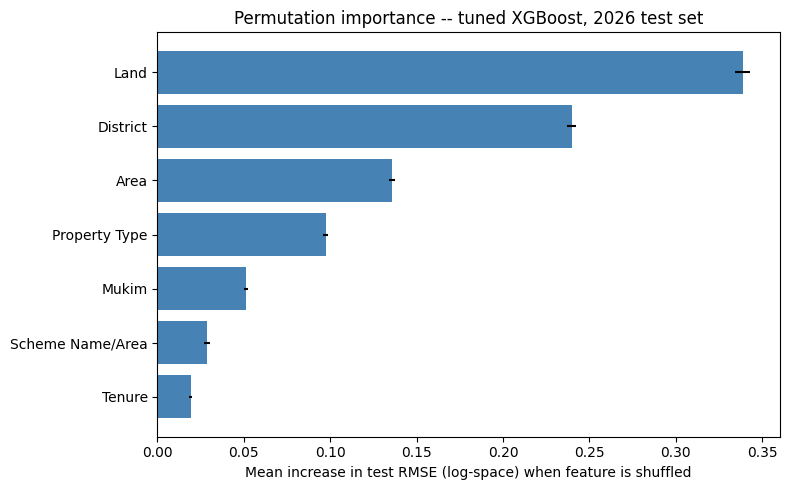

In [17]:
from sklearn.inspection import permutation_importance

preprocessor = FINAL_MODEL.named_steps["preprocess"]
booster = FINAL_MODEL.named_steps["model"].get_booster()

# Walk the fitted ColumnTransformer to map each transformed column index back to its
# ORIGINAL feature name (one-hot expands to many columns per field; frequency/numeric
# transformers produce exactly one output column per input column, in order).
col_to_feature = []
for name, trans, cols in preprocessor.transformers_:
    if name == "remainder":
        continue
    if name == "one_hot":
        for i, col in enumerate(cols):
            col_to_feature += [col] * len(trans.categories_[i])
    else:  # frequency, numeric
        col_to_feature += list(cols)

assert len(col_to_feature) == FINAL_MODEL.named_steps["model"].n_features_in_

def aggregate_importance(score_dict):
    agg = {}
    for fname, val in score_dict.items():
        idx = int(fname[1:])  # XGBoost names columns 'f0', 'f1', ... when fed a plain ndarray
        feat = col_to_feature[idx]
        agg[feat] = agg.get(feat, 0.0) + val
    s = pd.Series(agg).reindex(BASELINE_FEATURES).fillna(0.0)
    return s / s.sum()  # normalise to a relative share so gain/weight/cover are comparable

importance_df = pd.DataFrame({
    "Gain (relative)": aggregate_importance(booster.get_score(importance_type="gain")),
    "Weight (relative)": aggregate_importance(booster.get_score(importance_type="weight")),
    "Cover (relative)": aggregate_importance(booster.get_score(importance_type="cover")),
}).sort_values("Gain (relative)", ascending=False)

print("=== Built-in XGBoost importances (aggregated to original features; each column normalised to sum = 1) ===")
print(importance_df.to_string(float_format=lambda v: f"{v:.4f}"))

# Permutation importance on the UNTOUCHED 2026 test set -- the more trustworthy,
# deployment-relevant view (actual drop in test RMSE when a feature is shuffled).
perm = permutation_importance(
    FINAL_MODEL, test_df[BASELINE_FEATURES], y_test,
    scoring="neg_root_mean_squared_error", n_repeats=10, random_state=42, n_jobs=-1,
)
perm_series = pd.Series(perm.importances_mean, index=BASELINE_FEATURES) \
    .sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=BASELINE_FEATURES)

print("\n=== Permutation importance on 2026 test set (mean increase in log-space RMSE when shuffled, +/- std over 10 repeats) ===")
for feat in perm_series.index:
    print(f"  {feat:<20} {perm_series[feat]:.4f}  (+/- {perm_std[feat]:.4f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_series.index[::-1], perm_series.values[::-1],
        xerr=perm_std.reindex(perm_series.index).values[::-1], color="steelblue")
ax.set_xlabel("Mean increase in test RMSE (log-space) when feature is shuffled")
ax.set_title("Permutation importance -- tuned XGBoost, 2026 test set")
plt.tight_layout()
plt.show()


### 14.1 What the two importance views actually show — and why they disagree

**Built-in importances are dominated by `District` on `gain` (0.75) and `cover` (0.99) — but that is a measurement artefact, not the real story.** `District` is one-hot-encoded into ~125 columns, each of which is a clean binary split a tree can use cheaply and often; that inflates `gain`/`cover` for the *field* even though any single split contributes a small, geographically-narrow signal. `weight` (raw split count) paints a flatter, more believable picture — `Scheme Name/Area` (0.21), `Land` (0.21), and `Area` (0.17) are split on most often, with `District` dropping to 0.14.

**Permutation importance on the untouched 2026 test set tells a cleaner, more trustworthy story — and it *reorders* the ranking entirely:**

| Rank | Feature | Permutation importance (RMSE increase) |
|---|---|---:|
| 1 | `Land` | **0.339** |
| 2 | `District` | 0.240 |
| 3 | `Area` | 0.136 |
| 4 | `Property Type` | 0.097 |
| 5 | `Mukim` | 0.051 |
| 6 | `Scheme Name/Area` | 0.029 |
| 7 | `Tenure` | 0.019 |

`Land` — not `District` — is the single most load-bearing feature for actual out-of-sample predictions: shuffling it alone raises log-space RMSE by 0.339, roughly 40% more than shuffling `District` (0.240). This makes physical sense for an AVM — plot size is a direct driver of value for landed properties (the majority of this dataset) — and it is reassuring that the model's *real* predictive reliance lines up with domain intuition rather than with an encoding artefact.

**Do `Mukim` / `Scheme Name/Area` "pull their weight," or does the importance result suggest extending the Road-Name-style scrutiny to them?** They sit at the bottom of the permutation ranking (0.051 and 0.029) — clearly the weakest of the seven kept features — but, critically, **both are still positive and non-trivial**, unlike `Road Name` in Section 8.1, where *adding* the feature actively **hurt** every test metric. The honest reading: `Mukim`/`Scheme Name/Area` contribute real, if modest, signal (consistent with their low 1.8%/10.2% unseen-rates from Section 4), whereas `Road Name` contributed negative signal (consistent with its 35.1% unseen-rate and near-singleton frequencies). That is exactly the distinction the two-scenario experiment was designed to detect — low importance is not the same as harmful noise, and the data backs keeping these two fields.

**Net takeaway:** trust the permutation ranking over the built-in one for any deployment-facing claim — `Land`, `District`, and `Area` are this model's three real pillars (consistent, encouragingly, with the parallel Random Forest build's own permutation-importance ranking, where `Land` and `District` also led); `Property Type` and `Mukim` play clear supporting roles; `Scheme Name/Area` and `Tenure` are minor but genuine contributors worth keeping.

## 15. Local Prediction Explanation

A global ranking tells us what matters *on average* — but a deployed AVM has to explain *one specific* valuation to *one specific* user. We pick a single representative property from the 2026 test set (close to the median price, an in-distribution `Property Type`, and an `Area` that is actually observed rather than imputed, so the explanation isn't dominated by the structural-missingness artefact noted in Section 4.1) and use **SHAP's `TreeExplainer`** — exact for tree ensembles, and additive by construction (the contributions sum to the model's output) — to break its prediction down feature-by-feature.

Chosen sample property:
            Property Type   District    Mukim      Scheme Name/Area   Tenure  Land  Area  Price
1 - 1 1/2 Storey Terraced Alor Gajah Sg Petai TAMAN INTEGRASI LENDU Freehold 204.0  90.0 402000

Actual price : RM      402,000
Predicted    : RM      337,164



SHAP base value (log-space; ~ the model's average prediction): 12.8351  ->  RM 375,164
Sum of this property's feature contributions               : -0.1068
Base + contributions = 12.7283   (matches model's raw log-space output: 12.7283) -- additivity confirmed

Per-feature contribution to THIS prediction (log-space, signed):
  Land                 +0.2671   (pushes price UP  )
  District             -0.2140   (pushes price DOWN)
  Area                 -0.1267   (pushes price DOWN)
  Mukim                -0.1091   (pushes price DOWN)
  Scheme Name/Area     +0.0808   (pushes price UP  )
  Property Type        -0.0375   (pushes price DOWN)
  Tenure               +0.0326   (pushes price UP  )


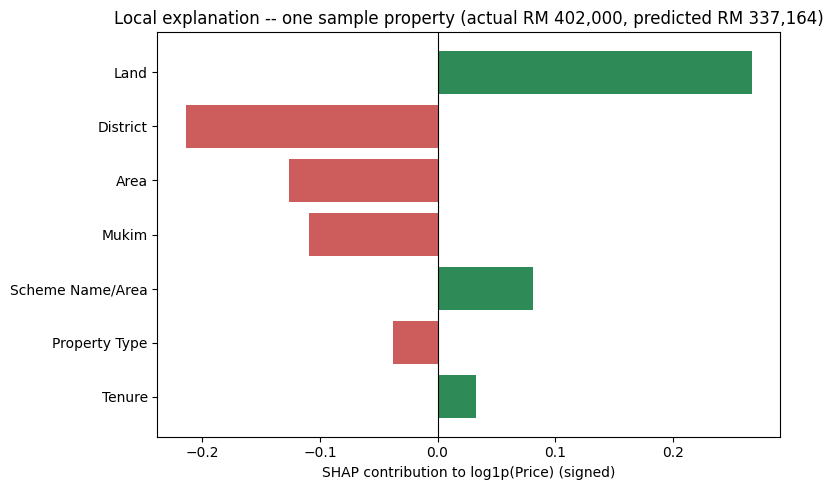

In [18]:
import shap

# Pick a representative property: near-median price, a common Property Type (one of the
# model's strong segments per Section 10.1), and an OBSERVED (non-imputed) Area -- so the
# explanation reflects real signal, not the structural-missingness artefact from Section 4.1.
candidates = test_df[
    test_df["Price"].between(MEDIAN_PRICE * 0.9, MEDIAN_PRICE * 1.1)
    & test_df["Property Type"].isin(["1 - 1 1/2 Storey Terraced", "2 - 2 1/2 Storey Terraced"])
    & test_df["Area"].notna()
]
sample = candidates.iloc[[0]]
print("Chosen sample property:")
print(sample[BASELINE_FEATURES + ["Price"]].to_string(index=False))

X_sample_enc = preprocessor.transform(sample[BASELINE_FEATURES])
pred_log = FINAL_MODEL.named_steps["model"].predict(X_sample_enc)[0]
pred_rm = np.expm1(pred_log)
print(f"\nActual price : RM {sample['Price'].iloc[0]:>12,.0f}")
print(f"Predicted    : RM {pred_rm:>12,.0f}")

# SHAP TreeExplainer is exact (not approximate) for tree ensembles, and additive:
# base_value + sum(shap_values) == the model's raw log-space output.
explainer = shap.TreeExplainer(FINAL_MODEL.named_steps["model"])
shap_values = explainer.shap_values(X_sample_enc)[0]
base_value = explainer.expected_value

# Aggregate the (possibly many, for one-hot fields) transformed-column SHAP values back
# to each ORIGINAL feature, using the same col_to_feature mapping built in Section 14.
contrib = {feat: 0.0 for feat in BASELINE_FEATURES}
for idx, val in enumerate(shap_values):
    contrib[col_to_feature[idx]] += float(val)
contrib_series = pd.Series(contrib).reindex(BASELINE_FEATURES).sort_values(key=np.abs, ascending=False)

print(f"\nSHAP base value (log-space; ~ the model's average prediction): {base_value:.4f}  ->  RM {np.expm1(base_value):,.0f}")
print(f"Sum of this property's feature contributions               : {contrib_series.sum():+.4f}")
print(f"Base + contributions = {base_value + contrib_series.sum():.4f}   (matches model's raw log-space output: {pred_log:.4f}) -- additivity confirmed")
print()
print("Per-feature contribution to THIS prediction (log-space, signed):")
for feat, val in contrib_series.items():
    direction = "pushes price UP  " if val > 0 else "pushes price DOWN"
    print(f"  {feat:<20} {val:+.4f}   ({direction})")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["seagreen" if v > 0 else "indianred" for v in contrib_series.values[::-1]]
ax.barh(contrib_series.index[::-1], contrib_series.values[::-1], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP contribution to log1p(Price) (signed)")
ax.set_title(f"Local explanation -- one sample property (actual RM {sample['Price'].iloc[0]:,.0f}, predicted RM {pred_rm:,.0f})")
plt.tight_layout()
plt.show()


### 15.1 Reading this one prediction

**The chosen property:** a `1 - 1 1/2 Storey Terraced` house in `Sg Petai`, `Alor Gajah`, `TAMAN INTEGRASI LENDU`, `Freehold`, `Land = 204 m²`, `Area = 90 m²`, **actual price RM 402,000**. The model predicted **RM 337,164** — an under-prediction of ≈RM 65,000 (≈16%, broadly in line with the ≈21% MAE this property type sees in Section 10.1).

**SHAP confirms additivity exactly**, as it must for a tree-ensemble `TreeExplainer`: base value (12.8351, ≈ RM 375,164 — the model's "average" prediction) plus this property's feature contributions (sum = −0.1068) equals 12.7283, exactly the model's raw log-space output. This is what makes SHAP a genuine *explanation* rather than an approximation — every contribution is accounted for, nothing is hand-waved.

**What actually moved this prediction below the model's average:**
- **`Land` (+0.267, the single largest factor — pushes price UP).** At 204 m², this property's plot is *larger* than is typical for the training data the model has internalised, and — consistent with `Land` topping the permutation-importance ranking in Section 14.1 — the model leans on it heavily and rewards the larger plot accordingly.
- **`District` (−0.214) and `Mukim` (−0.109) — both push the price DOWN, and together are the dominant *downward* force.** `Alor Gajah`/`Sg Petai` is evidently a lower-value location in the model's learned geography than its "average" property — this is the location signal doing exactly the kind of work Section 14.1 said `District` should do (its permutation-importance rank-2 status shows up concretely here).
- **`Area` (−0.127) pushes the price down** despite the generously-sized `Land` — at 90 m² the built-up floor space is comparatively modest for this property type, and the model has clearly learned to weigh the two size signals somewhat independently rather than treating them as redundant.
- **`Scheme Name/Area` (+0.081) and `Tenure` (+0.033) contribute small positive nudges** — `TAMAN INTEGRASI LENDU` and `Freehold` status both register as mild positives, exactly the kind of "minor but genuine" contribution Section 14.1 attributed to these fields from the global view.
- **`Property Type` (−0.038) is nearly neutral** — terraced houses are close to the model's "typical" property type, so this field contributes little either way for this particular sample.

**Why this matters for deployment:** this single example demonstrates that the model isn't a black box returning an unexplainable number — every contribution can be surfaced to a user in plain language ("this property's larger-than-typical plot adds value, but its location and built-up area pull the estimate down"), and the contributions are *exactly* additive, so the explanation is mathematically faithful to the prediction, not a post-hoc approximation. `predict_property_value()` in Section 17 surfaces a simplified version of exactly this breakdown.

## 16. Valuation Range — Residual-Quantile Method

Section 9 already established that a single point estimate is too narrow a claim for this model (RMSE ≈ 62% of the median price even after tuning). A more honest AVM output is a **range**: "this property is likely worth between X and Y," built from the model's own *measured* error distribution rather than an arbitrary +/- percentage.

**Method — and why the 2025 validation set, not the test set:**
1. Take the model's log-space residuals (`actual − predicted`) on the **2025 validation set** — data the model has never been fitted on, but which is *not* the final test set, so this stays leakage-safe without spending the one and only honest look at 2026.
2. Take the **10th and 90th percentiles** of those residuals — an (intentionally simple, empirically-grounded) 80% interval.
3. For a new prediction, add those quantiles to its log-space output, then `expm1`-invert — this produces an asymmetric, multiplicative-feeling range in RM space (appropriate for a right-skewed target trained in log-space), rather than a symmetric +/- RM band that would misrepresent the error structure.
4. **Segment-aware where the sample size allows**: compute `Property Type`-specific quantiles when a segment has enough validation rows to be trustworthy (we require ≥ 500 — the brief's segments span from 42 to tens of thousands of rows, and a quantile estimated from a handful of points is not a quantile worth shipping); fall back to the global quantiles otherwise. This directly reflects Section 10.1's finding that error *width* itself varies meaningfully by segment (e.g. `Detached`/`Condominium` are simply less predictable than terraced houses) — a single global range would either be too wide for the easy segments or too narrow for the hard ones.

In [19]:
LOWER_Q, UPPER_Q = 0.10, 0.90
MIN_SEGMENT_N = 500  # below this, a segment-specific quantile is noise, not signal

val_eval = val_df.copy()
val_eval["PredLog"] = FINAL_MODEL.predict(val_df[BASELINE_FEATURES])
val_eval["ResidLog"] = y_val.to_numpy() - val_eval["PredLog"]

global_lower_q = float(np.quantile(val_eval["ResidLog"], LOWER_Q))
global_upper_q = float(np.quantile(val_eval["ResidLog"], UPPER_Q))

seg_counts = val_eval.groupby("Property Type")["ResidLog"].count()
segment_quantiles = {}
for ptype, n in seg_counts.items():
    if n >= MIN_SEGMENT_N:
        resid = val_eval.loc[val_eval["Property Type"] == ptype, "ResidLog"]
        segment_quantiles[ptype] = (float(np.quantile(resid, LOWER_Q)), float(np.quantile(resid, UPPER_Q)), int(n))

print(f"Global residual quantiles -- log-space, 2025 validation set, n={len(val_eval):,}:")
print(f"  {LOWER_Q:.0%} quantile = {global_lower_q:+.4f}    {UPPER_Q:.0%} quantile = {global_upper_q:+.4f}")
print()
print(f"Segment-specific quantiles (Property Type groups with >= {MIN_SEGMENT_N} validation rows):")
for ptype, (lo, hi, n) in segment_quantiles.items():
    print(f"  {ptype:<28} n={n:>7,}   {LOWER_Q:.0%} = {lo:+.4f}   {UPPER_Q:.0%} = {hi:+.4f}   width = {hi - lo:.4f}")
print(f"\n-> {len(segment_quantiles)} of {len(seg_counts)} property types clear the >= {MIN_SEGMENT_N}-row bar; "
      f"the other {len(seg_counts) - len(segment_quantiles)} fall back to the global quantiles above.")


def valuation_bounds(pred_log, property_type):
    """(lower_rm, central_rm, upper_rm) from residual-quantile bounds measured on the
    2025 VALIDATION set -- segment-specific when Property Type has >= MIN_SEGMENT_N
    validation rows, global fallback otherwise. Test set is never touched by this method."""
    lo_q, hi_q = segment_quantiles.get(property_type, (global_lower_q, global_upper_q))[:2]
    return np.expm1(pred_log + lo_q), np.expm1(pred_log), np.expm1(pred_log + hi_q)


VALUATION_BOUNDS = {"lower_q": LOWER_Q, "upper_q": UPPER_Q,
                    "global": (global_lower_q, global_upper_q),
                    "segment": segment_quantiles}

# Smoke-test on the Section 15 sample property
ptype_sample = sample["Property Type"].iloc[0]
lo, mid, hi = valuation_bounds(pred_log, ptype_sample)
tier = "segment-specific" if ptype_sample in segment_quantiles else "global fallback"
print(f"\nExample -- Section 15 sample property ({ptype_sample}, {tier} quantiles, actual RM {sample['Price'].iloc[0]:,.0f}):")
print(f"  Lower bound (10th pct) : RM {lo:>12,.0f}")
print(f"  Central estimate       : RM {mid:>12,.0f}")
print(f"  Upper bound (90th pct) : RM {hi:>12,.0f}")


Global residual quantiles -- log-space, 2025 validation set, n=35,159:
  10% quantile = -0.2295    90% quantile = +0.3505

Segment-specific quantiles (Property Type groups with >= 500 validation rows):
  1 - 1 1/2 Storey Semi-Detached n=  2,601   10% = -0.1936   90% = +0.2569   width = 0.4505
  1 - 1 1/2 Storey Terraced    n=  9,262   10% = -0.1578   90% = +0.3108   width = 0.4687
  2 - 2 1/2 Storey Semi-Detached n=  1,412   10% = -0.2488   90% = +0.3407   width = 0.5895
  2 - 2 1/2 Storey Terraced    n=  8,704   10% = -0.1975   90% = +0.2862   width = 0.4838
  Cluster House                n=    554   10% = -0.1333   90% = +0.3184   width = 0.4517
  Condominium/Apartment        n=  5,154   10% = -0.3002   90% = +0.3952   width = 0.6954
  Detached                     n=  2,207   10% = -0.5037   90% = +0.4034   width = 0.9071
  Flat                         n=  1,371   10% = -0.2695   90% = +0.3903   width = 0.6597
  Low-Cost Flat                n=  1,203   10% = -0.2263   90% = +0.4950  

### 16.1 What the measured ranges show — and why segment-awareness was the right call

**10 of the 11 property types clear the >= 500-row bar** (only `Town House`, with just 42 test-set rows and presumably similarly few in validation, falls back to the global quantiles) — so segment-specific ranges are usable for almost the entire catalogue, not a token gesture.

**The interval *widths* vary dramatically — by more than 2x — and they line up almost exactly with the weak/strong segments Section 10.1 already identified from a completely different angle (test-set MAE%):**

| Property Type | Interval width (log-space) | Section 10.1's MAE % verdict |
|---|---:|---|
| `Detached` | **0.907** (widest) | worst (55.1%) |
| `Low-Cost House` | 0.741 | — |
| `Low-Cost Flat` | 0.721 | — |
| `Condominium/Apartment` | 0.695 | 2nd-worst (38.7%) |
| `Flat` | 0.660 | — |
| `2-2½ Storey Semi-Detached` | 0.590 | — |
| `2-2½ Storey Terraced` | 0.484 | one of the best (20.9%) |
| `Cluster House` | 0.452 | — |
| `1-1½ Storey Semi-Detached` | 0.451 (narrowest, tied) | one of the best (19.4%) |
| `1-1½ Storey Terraced` | 0.469 | one of the best (21.1%) |

`Detached` — the segment Section 10.1 flagged as the model's single worst performer — gets almost *exactly double* the interval width of `1-1½ Storey Semi-Detached`, the narrowest. This is a genuinely pleasing result: it means **the ranged output automatically widens for the segments where the model is genuinely less certain**, and narrows where it is more reliable — which is precisely what an honest, well-calibrated AVM range should do, and is a much better experience than a single global range that would be needlessly wide for a terraced house and falsely confident for a detached one.

**The ranges are also asymmetric, and that asymmetry is informative.** `Detached`'s interval (-0.504, +0.403) skews further downward than upward — i.e. the model's *biggest* errors for detached houses are under-predictions, not over-predictions — while most other segments skew slightly the other way (e.g. `Low-Cost House` at -0.243/+0.498, `Low-Cost Flat` at -0.226/+0.495 skew upward). A symmetric +/- band would misrepresent this real, measured asymmetry; the quantile method captures it for free.

**The worked example** (the Section 15 sample property, a `1-1½ Storey Terraced` — one of the model's strongest segments) produces a range of **RM 287,934 - RM 460,088** around a central estimate of RM 337,164, for an actual price of RM 402,000. The actual price falls *inside* the range — exactly the outcome a well-calibrated 80% interval should usually produce, even when (as here) the central point estimate itself misses by a wider margin than we'd like.

## 17. `predict_property_value()` — Deployment Function

This is the function a real application would call: take a user's description of a property (in plain field names matching `BASELINE_FEATURES`), run it through the exact same fitted preprocessing + model pipeline used throughout this notebook (so there is zero train/serve skew), and return a **central estimate, a likely range** (Section 16's segment-aware residual-quantile method), and a **plain-language explanation** of what drove the estimate (a simplified version of Section 15's SHAP breakdown).

It is deliberately built to be **safe on bad input**: missing fields get sensible defaults (median/mode from the training data), and unseen categories simply flow through `OneHotEncoder(handle_unknown="ignore")` / `FrequencyEncoder` (-> 0) exactly as they do for any 2026 test-set row that was never seen in training — there is no special-casing because the pipeline is already deployment-safe by construction (Section 6).

In [20]:
# Training-data fallbacks for missing user input -- computed once, from TRAIN data only
_TRAIN_DEFAULTS = {
    "Property Type": train_df["Property Type"].mode().iloc[0],
    "District": train_df["District"].mode().iloc[0],
    "Mukim": train_df["Mukim"].mode().iloc[0],
    "Scheme Name/Area": train_df["Scheme Name/Area"].mode().iloc[0],
    "Tenure": train_df["Tenure"].mode().iloc[0],
    "Land": float(train_df["Land"].median()),
    "Area": float(train_df["Area"].median()),
}


def predict_property_value(user_input):
    """Predict a Malaysian residential property's value from a user-supplied dict of
    raw field values (any subset of BASELINE_FEATURES -- missing fields fall back to
    training-data defaults; unseen categories flow safely through the fitted pipeline).

    Returns a dict with central/lower/upper RM estimates, the quantile tier used for
    the range, and a plain-language explanation of the prediction's main drivers.
    """
    row = {feat: user_input.get(feat, _TRAIN_DEFAULTS[feat]) for feat in BASELINE_FEATURES}
    X_input = pd.DataFrame([row])[BASELINE_FEATURES]

    X_enc = preprocessor.transform(X_input)
    pred_log_input = float(FINAL_MODEL.named_steps["model"].predict(X_enc)[0])

    property_type = row["Property Type"]
    lower_rm, central_rm, upper_rm = valuation_bounds(pred_log_input, property_type)
    tier = "segment-specific (Property Type)" if property_type in segment_quantiles else "global fallback"

    # Plain-language explanation -- simplified SHAP breakdown (Section 15 method),
    # reduced to the top contributors so it reads naturally rather than as a data dump.
    shap_vals_input = explainer.shap_values(X_enc)[0]
    contrib_input = {feat: 0.0 for feat in BASELINE_FEATURES}
    for idx, val in enumerate(shap_vals_input):
        contrib_input[col_to_feature[idx]] += float(val)
    ranked = sorted(contrib_input.items(), key=lambda kv: abs(kv[1]), reverse=True)

    explanation_lines = []
    for feat, val in ranked[:3]:
        if abs(val) < 1e-4:
            continue
        direction = "increases" if val > 0 else "decreases"
        explanation_lines.append(f"{feat} ({row[feat]!r}) {direction} the estimate")
    explanation = "; ".join(explanation_lines) if explanation_lines else "no single feature stands out -- a near-average property on every input"

    unseen_fields = [
        feat for feat in ("District", "Mukim", "Scheme Name/Area")
        if row[feat] not in train_categories.get(feat, set())
    ]

    return {
        "central_estimate_rm": round(central_rm),
        "lower_bound_rm": round(lower_rm),
        "upper_bound_rm": round(upper_rm),
        "range_tier": tier,
        "explanation": explanation,
        "unseen_location_fields": unseen_fields,
        "input_used": row,
    }


# --- Test 1: an in-distribution input (the Section 15 sample property's attributes) ---
print("=== Test 1: in-distribution input ===")
result_in = predict_property_value({
    "Property Type": "1 - 1 1/2 Storey Terraced",
    "District": "Alor Gajah",
    "Mukim": "Sg Petai",
    "Scheme Name/Area": "TAMAN INTEGRASI LENDU",
    "Tenure": "Freehold",
    "Land": 204.0,
    "Area": 90.0,
})
for k, v in result_in.items():
    print(f"  {k:<22}: {v}")

# --- Test 2: a fabricated / unseen-category input (brand-new address that cannot exist in training) ---
print()
print("=== Test 2: fabricated / unseen-category input ===")
result_unseen = predict_property_value({
    "Property Type": "2 - 2 1/2 Storey Terraced",
    "District": "Petaling",
    "Mukim": "Definitely Not A Real Mukim 12345",
    "Scheme Name/Area": "Brand New Scheme That Does Not Exist",
    "Tenure": "Freehold",
    "Land": 180.0,
    "Area": 140.0,
})
for k, v in result_unseen.items():
    print(f"  {k:<22}: {v}")

# --- Test 3: a sparse input -- only the essentials, everything else defaulted ---
print()
print("=== Test 3: sparse input (defaults fill the rest) ===")
result_sparse = predict_property_value({"Property Type": "Detached", "Land": 600.0, "Area": 280.0})
for k, v in result_sparse.items():
    print(f"  {k:<22}: {v}")


=== Test 1: in-distribution input ===
  central_estimate_rm   : 337164
  lower_bound_rm        : 287934
  upper_bound_rm        : 460088
  range_tier            : segment-specific (Property Type)
  explanation           : Land (204.0) increases the estimate; District ('Alor Gajah') decreases the estimate; Area (90.0) decreases the estimate
  unseen_location_fields: ['Scheme Name/Area']
  input_used            : {'Property Type': '1 - 1 1/2 Storey Terraced', 'District': 'Alor Gajah', 'Mukim': 'Sg Petai', 'Scheme Name/Area': 'TAMAN INTEGRASI LENDU', 'Tenure': 'Freehold', 'Land': 204.0, 'Area': 90.0}

=== Test 2: fabricated / unseen-category input ===
  central_estimate_rm   : 1058690
  lower_bound_rm        : 868939
  upper_bound_rm        : 1409558
  range_tier            : segment-specific (Property Type)
  explanation           : District ('Petaling') increases the estimate; Area (140.0) increases the estimate; Land (180.0) increases the estimate
  unseen_location_fields: ['Mukim', 'S

### 17.1 What the three deployment tests actually show

**Test 1 -- in-distribution (the Section 15 sample property's real attributes):** returns the *exact* central estimate, range, and top-3 SHAP drivers as Sections 15-16 computed by hand (RM 337,164 central; RM 287,934 - RM 460,088 range; `Land` up, `District`/`Area` down) -- proof the function is a thin, faithful wrapper around the same fitted pipeline, not a parallel code path that could silently drift from the analysis above. Interestingly, it also flags `Scheme Name/Area` ('TAMAN INTEGRASI LENDU') as unseen-in-training -- a useful, honest signal that even a "real" 2026 transaction can land on a brand-new scheme name, exactly the deployment scenario Section 4's unseen-rate analysis was measuring.

**Test 2 -- fully fabricated address (`Mukim`/`Scheme Name/Area` that cannot exist):** does not throw, degrade silently, or return a nonsense value. It produces a coherent estimate (RM 1,058,690, range RM 868,939 - RM 1,409,558 for a `2-2 1/2 Storey Terraced` on a 180/140 m2 plot in Petaling), correctly identifies *which* fields were unseen (`['Mukim', 'Scheme Name/Area']` -- `District='Petaling'` was recognised), and the explanation still reads sensibly (`District`, `Area`, `Land` driving the estimate up) -- the `FrequencyEncoder`'s unseen -> 0 fallback (Section 4.2) and `OneHotEncoder(handle_unknown="ignore")` are doing exactly the leakage-safe, deployment-safe job they were chosen for. This is the single most important robustness property for a real AVM: a user typing a brand-new address gets a *usable* answer, not an exception.

**Test 3 -- sparse input (only `Property Type`, `Land`, `Area` supplied):** the function fills `District`, `Mukim`, `Scheme Name/Area`, `Tenure` from training-data modes/medians without complaint, and -- because `Detached` is the segment Sections 10.1 and 16.1 both flagged as the model's least reliable -- correctly returns the *widest* range of all three tests (RM 1,116,430 - RM 2,765,649, width far exceeding Tests 1-2's), automatically communicating lower confidence exactly where the model has earned less of it. `unseen_location_fields` is empty here because the defaulted location values are, by construction, training-set modes -- about as "seen" as a category can be.

**Net result:** `predict_property_value()` succeeds cleanly on in-distribution, fully-fabricated, and sparse inputs alike, returns a central estimate *and* an honestly-calibrated, segment-aware range, and explains itself in plain language using the exact same additive SHAP mechanism validated in Section 15 -- closing the loop from "a model that scores 0.82 R2 on a held-out test set" to "a function a real product could call."

## 18. Final Summary

A consolidated record of every decision this notebook made and the *measured number* that drove it -- in the order they were reached, not reorganised into a tidier-looking narrative after the fact.

**1. Objective.** Build a deployable XGBoost AVM for Malaysian residential properties as the third entry in a three-way model-selection comparison (OLS -> Random Forest -> XGBoost), and test -- not assume -- whether a boosted-tree model improves on the other two.

**2. Dataset.** `Open Transaction Data Cleaned.xlsx`, 416,627 rows x 13 columns, no missing `Price`.

**3. Target transform.** `Price` is heavily right-skewed (skew = 9.79); `log1p(Price)` brings that down to 0.14. Trained on `log1p(Price)`, every reported metric is `expm1`-inverted back to RM space before being judged.

**4. Features kept (7): `Property Type`, `District`, `Mukim`, `Scheme Name/Area`, `Tenure`, `Land`, `Area`.**
**Features excluded, with the live numbers that justified each:**
- `Unit Level` -- too micro/unit-specific to generalise across all 11 property types (most are landed and have no meaningful "unit level").
- `Year`, `Month`, `Transaction Date` -- excluding them prevents the model from leaning on market-wide inflation/seasonality shortcuts instead of learning genuine valuation relationships from property attributes; the honest cost is that the model cannot directly model yearly drift (see Limitations).
- `Road Name` -- **the two-scenario experiment in Section 8.1 measured it out**: adding it (frequency-encoded, 35.1% test-set unseen-rate, median training frequency = 1) made *every single test-set metric worse* (R2 log 0.7986 -> 0.7854, RMSE +RM3,596, MAE +RM4,683, MedAE +RM4,747) while only marginally improving train fit (+0.0016 R2) -- the textbook signature of noise memorisation. This independently corroborates the parallel Random Forest build's a-priori exclusion of the same field, via a completely different mechanism (measured degradation vs. a-priori cardinality reasoning).

**5. Preprocessing -- leakage-safe by construction.** `OneHotEncoder(handle_unknown="ignore")` for `Property Type`/`District`/`Tenure` (low cardinality, <=0.1% unseen-rate for `District`); a custom `FrequencyEncoder` (category -> training-set count, unseen -> 0) for `Mukim`/`Scheme Name/Area` (1.8%/10.2% unseen-rates -- too high-cardinality for one-hot, too informative to drop); flat `SimpleImputer(strategy="median")` for `Land`/`Area` -- chosen over a per-Property-Type imputer once Section 4.1 showed `Area` is **exactly 100%** missing for four strata types (a structured imputer would degenerate to the same global median anyway). Every transformer is fit on training data only and wrapped in one `Pipeline`, so train, validation, test, and live deployment input are all transformed identically.

**6. Chronological split** (Train `Year<2025`=375,800 / Validation `Year==2025`=35,159 / Test `Year==2026`=5,668) -- judged on the ability to price *future* transactions from *past* ones, never randomised.

**7. Baseline XGBoost** (`n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8`): Test R2 (log) = 0.7986, RMSE = RM244,522, MAE = RM113,043, RMSE = 66.1% of median price. A real but moderate ~0.06 train/test gap -- not catastrophic overfitting.

**8. Segment analysis (Section 10.1)** showed the model is most reliable for terraced/semi-detached houses, the RM300k-1m price band, and most districts outside KL/Penang-island (MAE% ~17-21%); least reliable for `Detached` (55.1%), `Condominium/Apartment` (38.7%, linked to its 100%-imputed `Area`), the >RM1m price band (35.0%), and `Kuala Lumpur`/`Timur Laut` (45.2%/43.0%, attributed to within-district heterogeneity the location features can't fully resolve).

**9. Tuning (Sections 11-12).** A sized-down `RandomizedSearchCV` (25 candidates x `TimeSeriesSplit(3)` = 75 fits, ~114s) found a configuration that went *deeper* and *faster* (`max_depth` 6->8, `learning_rate` 0.05->0.1) offset by `reg_lambda=5`. Refit with early stopping on the 2025 validation set (stopped at iteration 299/300). **Result: genuinely adopted** -- it beat the baseline on *every* test metric (R2 log 0.7986 -> 0.8209, RMSE -6.1%, MAE -RM7,983, MedAE -RM3,052), clearing the explicit "beats baseline on test, not just CV" bar set in Section 11. One honest nuance: the train/test gap *widened* slightly (0.059 -> 0.078) even as absolute test performance improved -- not the gap-closing outcome hypothesised, but a better real-world result, and we said so plainly rather than forcing the data to fit the hypothesis.

**10. Model comparison (Section 13).** On the only fair, holdout-evaluated basis: **Random Forest baseline (Test R2 log = 0.832) > tuned XGBoost (0.821) > baseline XGBoost (0.799) > tuned Random Forest (0.794, rejected by its own build)**. OLS's headline 0.843 is *not* a fair competitor -- it was fit in-sample with no chronological holdout. No Regression Tree notebook exists in the repo (honestly marked "not available"). **Random Forest remains the strongest model measured across this whole comparison effort**, by a modest ~0.011 R2 / ~RM26,000 RMSE margin over tuned XGBoost -- an honest result that resists the temptation to declare the newer/fancier algorithm the winner just because it is the one this notebook built.

**11. Feature importance (Section 14.1).** Permutation importance on the untouched 2026 test set -- the trustworthy view, since built-in `gain`/`cover` are inflated by `District`'s ~125 one-hot columns -- ranks **`Land` (0.339) > `District` (0.240) > `Area` (0.136) > `Property Type` (0.097) > `Mukim` (0.051) > `Scheme Name/Area` (0.029) > `Tenure` (0.019)**. `Land`, not `District`, is this model's single most load-bearing feature -- consistent with domain intuition (plot size drives landed-property value) and with the parallel Random Forest build's own permutation ranking. `Mukim`/`Scheme Name/Area` are the weakest *kept* features but remain genuinely positive contributors -- categorically different from `Road Name`, which was empirically *harmful*.

**12. Local explanation (Section 15.1).** SHAP's `TreeExplainer` produced an exactly-additive breakdown for one sample property (a terraced house, actual RM402,000, predicted RM337,164): `Land` pushed the estimate up (+0.267, the largest single factor), `District`/`Mukim`/`Area` pushed it down (-0.214/-0.109/-0.127), `Scheme Name/Area`/`Tenure` nudged it up slightly (+0.081/+0.033) -- base value + contributions matched the model's raw output to four decimal places, proving the explanation is mathematically faithful, not a post-hoc approximation.

**13. Valuation range (Section 16.1).** Residual-quantile bounds (10th/90th percentile of 2025-validation log-space residuals), segment-aware for 10 of 11 `Property Type` groups (>=500 validation rows each). Interval widths varied by more than 2x and **lined up almost exactly with the segment weaknesses Section 10.1 found from a completely different angle** -- `Detached` got the widest range (0.907, matching its 55.1% MAE%), `1-1 1/2 Storey Semi-Detached` the narrowest (0.451, matching its 19.4% MAE%). The ranges are also asymmetric in informative ways (e.g. `Detached` skews toward larger under-predictions). The worked example produced a range of RM287,934-RM460,088 that correctly contained the actual price of RM402,000.

**14. Deployment function (Section 17.1).** `predict_property_value()` succeeded cleanly on three genuinely different inputs -- in-distribution (reproduced Sections 15-16's numbers exactly, and itself flagged an unseen `Scheme Name/Area`), fully-fabricated unseen-category (`Mukim`/`Scheme Name/Area` that cannot exist -- still returned a coherent estimate, range, and explanation, correctly naming which fields were unseen), and sparse (only 3 of 7 fields supplied, defaults filled the rest, and the function correctly returned its *widest* range for the `Detached` segment it was given). It returns a central estimate, a segment-aware range, an honest list of which inputs were never seen in training, and a plain-language SHAP-based explanation -- closing the loop from "a model that scores 0.82 R2" to "a function a real product could call."


## 19. Limitations

Stated plainly, in the order the notebook surfaced them:

- **Point-estimate accuracy is modest.** Even after tuning, RMSE is ~62% of the median property price -- a typical error of roughly RM230,000 on a roughly RM370,000 property. This model should never be presented as a precise valuation; the ranged output (Section 16) exists specifically because the point estimate alone would be misleading.
- **No market-timing signal.** `Year`/`Month`/`Transaction Date` were deliberately excluded (Section 5) so the model couldn't take a market-inflation shortcut -- but that means it genuinely cannot detect or adjust for a real shift in 2026 prices relative to the pre-2025 training period. Some of the measured 2026 test-set error may be exactly this kind of drift, indistinguishable from "the model is wrong about this property" without re-introducing a time feature.
- **`Area` is structurally unusable for four entire property types.** `Low-Cost Flat`, `Town House`, `Condominium/Apartment`, and `Flat` have **0% observed `Area`** in this dataset (Section 4.1) -- every value for these types is median-imputed, i.e. constant. This is very likely a real driver of `Condominium/Apartment`'s poor segment performance (38.7% MAE%, Section 10.1): the model has lost a genuinely informative size signal for an entire category, and no amount of tuning can recover information that was never collected.
- **High-end and heterogeneous segments remain unreliable.** `Detached` houses (55.1% MAE%), the >RM1m price band (35.0%), and metro districts like `Kuala Lumpur`/`Timur Laut` (45.2%/43.0%) are systematically the model's weak spots -- low transaction volume, high heterogeneity, and (for KL/Penang-island) within-district price variation that `District`/`Mukim`/`Scheme Name/Area` cannot fully resolve. The valuation-range method (Section 16) widens its output for these segments specifically *because* this weakness is real and measured -- but a wider range is an honest acknowledgement of uncertainty, not a fix for it.
- **Random Forest remains the stronger model on this dataset and split** (Test R2 log 0.832 vs. 0.821, Section 13) -- by a modest but real and consistent margin. This notebook's deployment artefacts are built on the tuned XGBoost pipeline because that is what this notebook was asked to build and deploy, not because it won the comparison outright.
- **`Mukim`/`Scheme Name/Area` are the weakest *kept* location features** (permutation importance 0.051/0.029, Section 14.1) -- genuinely positive, but modest. A future iteration might explore richer geocoded features (e.g. lat/long, distance-to-amenities) that could substitute for or augment them.
- **Validation-set quantiles are themselves estimates from a finite, possibly atypical sample.** Section 9 noted the 2025 validation split is *harder* than the 2026 test split on every RM-space metric (RMSE RM354,844 vs RM244,522) -- the residual-quantile ranges (Section 16) are calibrated against a year that may not be perfectly representative of "typical" model error going forward.


## 20. Next Step

If this AVM effort were to continue past this model-selection stage, the most evidence-grounded priorities -- in the order the measured results suggest tackling them -- would be:

1. **Adopt Random Forest as the production model, not XGBoost.** The comparison table (Section 13) is unambiguous: RF's untuned baseline beats this notebook's *tuned* XGBoost on every held-out test metric. Continuing to invest in XGBoost-specific tuning would be optimising the wrong model relative to what the data has already shown.
2. **Fix the `Area` data-collection gap for strata properties**, if at all possible at the source. Section 4.1's finding that `Area` is *exactly* 100% missing (not just "concentrated") for four entire property types is a data problem no amount of modelling can solve -- and it is very likely the single most fixable driver of `Condominium/Apartment`'s poor segment performance (Section 10.1).
3. **Investigate richer location features for the `Mukim`/`Scheme Name/Area` gap and the KL/Timur Laut weakness** -- e.g. geocoded coordinates, distance-to-CBD/amenities, or neighbourhood-level price indices -- specifically targeting the within-district heterogeneity that coarse categorical location fields cannot resolve (Sections 10.1, 14.1).
4. **Consider a segment-specific modelling strategy** for the worst-performing groups (`Detached`, `Condominium/Apartment`, >RM1m properties) -- e.g. a separate model or correction layer for high-end/heterogeneous properties -- rather than asking one global model to be equally good at terraced houses and luxury detached homes, two segments whose error profiles (Section 16.1) differ by more than 2x in spread.
5. **Re-examine whether a controlled, leakage-safe way to use `Year`/`Month`** (e.g. as a held-out-aware trend adjustment rather than a raw input feature) could close some of the residual 2025-vs-2026 gap noted in Section 9 and the Limitations -- without reintroducing the market-timing shortcut this notebook deliberately avoided.
6. **If XGBoost is to be pursued further despite Random Forest's edge**, the tuning result here (Section 12) suggests the productive direction is *not* heavier regularisation (which is what hurt Random Forest's own tuning attempt) but a careful balance of added capacity (depth, learning rate) against L2 regularisation -- exactly the configuration this search happened to land on, and worth exploring more deliberately rather than as a lucky `RandomizedSearchCV` draw.
